In [40]:
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt

N = np.array([1, 5, 10, 20, 50, 100])
E = np.array([10000, 50000, 100000, 250000, 500000, 1000000])
TL = np.array([
    [30,  112, 178,  208,  438,  957],   # N = 1
    [11,  60,  111,  279,  687,  1225],  # N = 5
    [15,  78,  166,  494,  886,  1853],  # N = 10
    [27,  147, 305,  788,  1616, 3099],  # N = 20
    [62,  318, 672,  1580, 3323, 6143],  # N = 50
    [96,  550, 1145, 3025, 5834, 11184]  # N = 100
])
TB = np.array([
    [39,  128, 201,  390,  918,  1828],  # N = 1
    [16,  86,  179,  410,  892,  1773],  # N = 5
    [28,  125, 215,  566,  1057, 2255],  # N = 10
    [33,  150, 282,  822,  1656, 2902],  # N = 20
    [62,  289, 593,  1543, 3080, 6146],  # N = 50
    [108, 526, 1084, 2604, 5514, 11175]  # N = 100
])

In [41]:
figL = go.Figure(data=[go.Surface(z=TL, x=E, y=N)])
figL.update_layout(
    title="Linear T(N, E)",
    scene={
        'xaxis_title': 'Events (E)',
        'yaxis_title': 'Nodes (N)',
        'zaxis_title': 'Time (ms)'
    }
)

figL.show()

In [42]:
figB = go.Figure(data=[go.Surface(z=TB, x=E, y=N)])
figB.update_layout(
    title="Branched T(N, E)",
    scene={
        'xaxis_title': 'Events (E)',
        'yaxis_title': 'Nodes (N)',
        'zaxis_title': 'Time (ms)'
    }
)

figB.show()

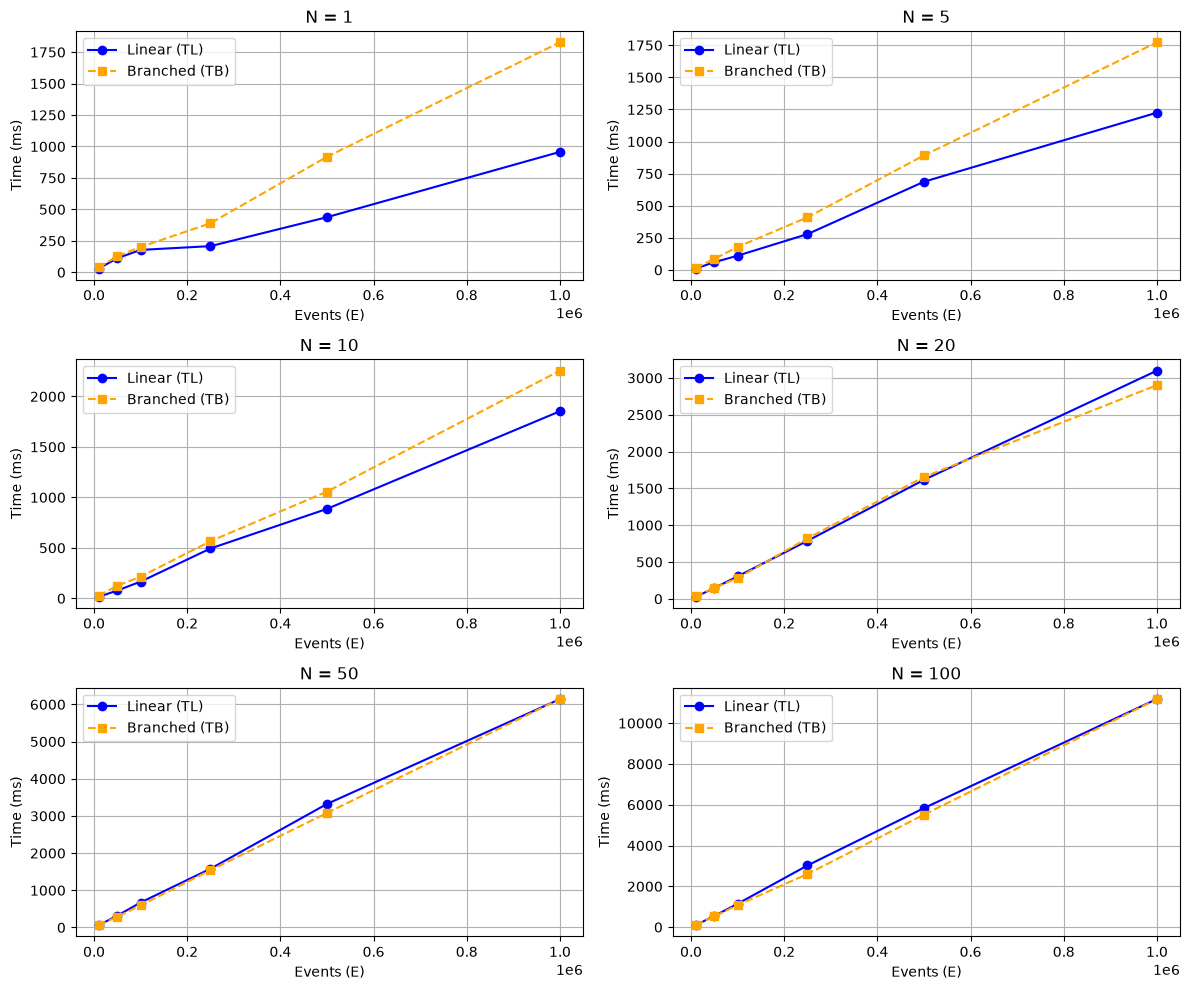

In [43]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, n in enumerate(N):
    ax = axes[i]
    ax.plot(E, TL[i], label='Linear (TL)', marker='o', color='blue')
    ax.plot(E, TB[i], label='Branched (TB)', marker='s', color='orange', linestyle='--')
    ax.set_title(f'N = {n}')
    ax.set_xlabel('Events (E)')
    ax.set_ylabel('Time (ms)')
    ax.grid(True)
    ax.legend()

if len(N) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

In [44]:
Delta_T = TL - TB

fig = go.Figure(data=[go.Surface(z=Delta_T, x=E, y=N, colorscale='RdBu')])

fig.update_layout(
    title="ΔT(N, E) = Linear - Branched",
    scene={
        'xaxis_title': 'Events (E)',
        'yaxis_title': 'Nodes (N)',
        'zaxis_title': 'ΔTime (ms)'
    }
)

fig.show()